# 08v2 — Model 1: XGBoost Regression — Prediksi Views (Fixed: No Data Leakage)

**Perbaikan dari v1:**
- Menghapus 8 fitur yang bocor (data leakage): `views_vs_channel_avg`, `peak_views`, `is_viral`, `is_top_performer`, `watch_time_hours`, `views_volatility`, `growth_*`, `view_velocity`, `subscriber_net`
- Menambahkan `ts1_views` (views snapshot awal) dari `abis_cleaning.csv` sebagai anchor feature utama
- Target tetap: `penayangan_tak_dilewati` (total views final)
- Output: 3 model horizon — ts2 (short), ts4 (medium), penayangan (long) + scaler_model1.pkl

**Ekspektasi R² yang realistis setelah leakage dihapus: 0.75–0.88**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── 1. LOAD DATA & MERGE TS1/TS2/TS4 FROM ABIS_CLEANING ──────────────────────
fm = pd.read_csv('../../data/processed/features_merged.csv')
abis = pd.read_csv('../../data/cleaned/abis_cleaning.csv')[[
    'video_id', 'ts1_views', 'ts2_views', 'ts4_views', 'penayangan_tak_dilewati'
]]

df = fm.merge(abis, on='video_id', how='inner').dropna(
    subset=['ts1_views', 'ts2_views', 'ts4_views', 'penayangan_tak_dilewati']
).reset_index(drop=True)

print(f'Shape setelah merge: {df.shape}')
print(f'ts1_views describe: mean={df["ts1_views"].mean():.0f}, median={df["ts1_views"].median():.0f}')

Shape setelah merge: (2351, 60)
ts1_views describe: mean=20037, median=6907


In [3]:
# ── 2. DEFINISI FITUR BERSIH (TANPA DATA LEAKAGE) ────────────────────────────
#
# LEAKAGE yang DIHAPUS:
#   views, views_vs_channel_avg (corr=1.0 dgn target)
#   peak_views (corr=0.975 — max dari ts columns)
#   is_viral, is_top_performer (threshold dari total views)
#   watch_time_hours (corr=0.969 — views × avg_duration)
#   views_volatility (corr=0.918 — std dari ts1-ts4)
#   growth_1_to_2, growth_2_to_3, growth_3_to_4, growth_trend, avg_growth_rate
#     (menggunakan ts2/ts3/ts4 yang belum tersedia saat prediksi awal)
#   view_velocity (corr=0.596 — views/age = total views dibagi usia)
#   subscriber_net (corr=0.903 — total subscriber gained over full life)
#
# ANCHOR FEATURE DITAMBAHKAN:
#   ts1_views — snapshot views pertama (tersedia saat input pengguna)

CLEAN_FEATURES = [
    # ── Views snapshot awal (anchor) ──
    'ts1_views',

    # ── Engagement (dihitung dari ts1 snapshot, tidak bocor) ──
    'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio',
    'engagement_score',

    # ── CTR & Impression ──
    'impression_to_view_rate', 'ctr_impression_score', 'ctr_vs_channel_avg',
    'impressions_log', 'ctr_category',

    # ── Rolling channel history (shift-1, tidak bocor) ──
    'rolling_mean_views_7d', 'rolling_avg_views_15', 'rolling_cv_views',
    'views_trend_ratio', 'decayed_historical_views', 'views_deviation',

    # ── Video metadata ──
    'video_age_days', 'day_of_week', 'month', 'is_weekend', 'video_duration_sec',

    # ── Revenue signals ──
    'revenue_per_view', 'is_monetized', 'ad_impression_rate', 'revenue_category',
    'revenue_idr_log',
]

CLEAN_FEATURES = [f for f in CLEAN_FEATURES if f in df.columns]
print(f'Total clean features: {len(CLEAN_FEATURES)}')
print(CLEAN_FEATURES)

Total clean features: 27
['ts1_views', 'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio', 'engagement_score', 'impression_to_view_rate', 'ctr_impression_score', 'ctr_vs_channel_avg', 'impressions_log', 'ctr_category', 'rolling_mean_views_7d', 'rolling_avg_views_15', 'rolling_cv_views', 'views_trend_ratio', 'decayed_historical_views', 'views_deviation', 'video_age_days', 'day_of_week', 'month', 'is_weekend', 'video_duration_sec', 'revenue_per_view', 'is_monetized', 'ad_impression_rate', 'revenue_category', 'revenue_idr_log']


In [4]:
# ── 3. ELIMINASI MULTIKOLINEARITAS (Korelasi > 0.85 antar fitur) ─────────────
X_raw = df[CLEAN_FEATURES].copy().fillna(0).replace([np.inf, -np.inf], 0)
y_long = np.log1p(df['penayangan_tak_dilewati'])  # target utama (long-term)

corr_matrix = X_raw.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = []
for col in upper.columns:
    hi_corr = upper.index[upper[col] > 0.85].tolist()
    for f in hi_corr:
        corr_col = abs(np.corrcoef(X_raw[col], y_long)[0, 1])
        corr_f   = abs(np.corrcoef(X_raw[f],   y_long)[0, 1])
        drop_candidate = col if corr_col < corr_f else f
        if drop_candidate not in to_drop:
            to_drop.append(drop_candidate)

SELECTED_FEATURES = [f for f in CLEAN_FEATURES if f not in to_drop]
print(f'Fitur dibuang karena multikolinearitas ({len(to_drop)}): {to_drop}')
print(f'Fitur final ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}')

X = X_raw[SELECTED_FEATURES].copy()

Fitur dibuang karena multikolinearitas (5): ['rolling_mean_views_7d', 'decayed_historical_views', 'ad_impression_rate', 'revenue_idr_log', 'revenue_category']
Fitur final (22): ['ts1_views', 'like_rate', 'dislike_rate', 'comment_rate', 'like_dislike_ratio', 'engagement_score', 'impression_to_view_rate', 'ctr_impression_score', 'ctr_vs_channel_avg', 'impressions_log', 'ctr_category', 'rolling_avg_views_15', 'rolling_cv_views', 'views_trend_ratio', 'views_deviation', 'video_age_days', 'day_of_week', 'month', 'is_weekend', 'video_duration_sec', 'revenue_per_view', 'is_monetized']


In [5]:
# ── 4. TRAIN/TEST SPLIT KRONOLOGIS 80/20 ─────────────────────────────────────
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# Siapkan 3 target: short (ts2), medium (ts4), long (penayangan_tak_dilewati)
y_short  = np.log1p(df['ts2_views'])
y_medium = np.log1p(df['ts4_views'])
y_long   = np.log1p(df['penayangan_tak_dilewati'])

for name, y in [('SHORT (ts2)', y_short), ('MEDIUM (ts4)', y_medium), ('LONG (penayangan)', y_long)]:
    print(f'{name}: train={split_idx} test={len(df)-split_idx}')

# Scaler (XGBoost tidak butuh scaling, tapi disimpan untuk konsistensi pipeline)
scaler_m1 = StandardScaler()
X_train_sc = scaler_m1.fit_transform(X_train)
X_test_sc  = scaler_m1.transform(X_test)
print('\nScaler fitted ✓')

SHORT (ts2): train=1880 test=471
MEDIUM (ts4): train=1880 test=471
LONG (penayangan): train=1880 test=471

Scaler fitted ✓


In [6]:
# ── 5. TRAIN 3 HORIZON MODELS ────────────────────────────────────────────────
def train_xgb(X_tr, y_tr, X_te, y_te, label):
    model = XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.1,
        reg_lambda=2.0,
        gamma=0.15,
        random_state=RANDOM_SEED,
        eval_metric='rmse',
        early_stopping_rounds=50,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_te, y_te)],
        verbose=False
    )
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    mape = np.mean(np.abs((np.expm1(y_te) - np.expm1(y_pred)) / (np.expm1(y_te) + 1e-9))) * 100
    print(f'[{label}] Best iter={model.best_iteration} | RMSE(log)={rmse:.4f} | R²={r2:.4f} | MAPE={mape:.2f}%')
    return model, rmse, r2, mape

print('=== Training 3 Models ===' )
model_short,  rmse_s, r2_s, mape_s = train_xgb(X_train_sc, y_short.iloc[:split_idx],  X_test_sc, y_short.iloc[split_idx:],  'SHORT  ts2 (≈7d)')
model_medium, rmse_m, r2_m, mape_m = train_xgb(X_train_sc, y_medium.iloc[:split_idx], X_test_sc, y_medium.iloc[split_idx:], 'MEDIUM ts4 (≈14d)')
model_long,   rmse_l, r2_l, mape_l = train_xgb(X_train_sc, y_long.iloc[:split_idx],   X_test_sc, y_long.iloc[split_idx:],  'LONG   penayangan')

=== Training 3 Models ===


[SHORT  ts2 (≈7d)] Best iter=485 | RMSE(log)=0.2299 | R²=0.9719 | MAPE=17.22%


[MEDIUM ts4 (≈14d)] Best iter=588 | RMSE(log)=0.2289 | R²=0.9747 | MAPE=17.53%


[LONG   penayangan] Best iter=442 | RMSE(log)=0.1040 | R²=0.9943 | MAPE=7.31%


In [7]:
# ── 6. TRAIN vs TEST OVERFITTING CHECK ───────────────────────────────────────
print('=== Train vs Test Gap Check ===')
for name, model, y_tr, y_te in [
    ('SHORT',  model_short,  y_short.iloc[:split_idx],  y_short.iloc[split_idx:]),
    ('MEDIUM', model_medium, y_medium.iloc[:split_idx], y_medium.iloc[split_idx:]),
    ('LONG',   model_long,   y_long.iloc[:split_idx],   y_long.iloc[split_idx:]),
]:
    r2_train = r2_score(y_tr, model.predict(X_train_sc))
    r2_test  = r2_score(y_te, model.predict(X_test_sc))
    gap = r2_train - r2_test
    status = '⚠️ OVERFIT' if gap > 0.05 else '✓ OK'
    print(f'  {name}: R²_train={r2_train:.4f} | R²_test={r2_test:.4f} | gap={gap:.4f} {status}')

=== Train vs Test Gap Check ===
  SHORT: R²_train=0.9930 | R²_test=0.9719 | gap=0.0211 ✓ OK
  MEDIUM: R²_train=0.9914 | R²_test=0.9747 | gap=0.0167 ✓ OK
  LONG: R²_train=0.9971 | R²_test=0.9943 | gap=0.0028 ✓ OK


In [8]:
# ── 7. 5-FOLD CV UNTUK MODEL LONG (PRIMARY) ───────────────────────────────────
kf = KFold(n_splits=5, shuffle=False)
cv_r2, cv_mape = [], []

cv_model = XGBRegressor(
    n_estimators=model_long.best_iteration + 1,
    learning_rate=0.03, max_depth=5, min_child_weight=5,
    subsample=0.80, colsample_bytree=0.80,
    reg_alpha=0.1, reg_lambda=2.0, gamma=0.15,
    random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
)

X_sc_all = scaler_m1.transform(X)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_sc_all), 1):
    Xtr, Xval = X_sc_all[tr_idx], X_sc_all[val_idx]
    ytr, yval = y_long.iloc[tr_idx], y_long.iloc[val_idx]
    cv_model.fit(Xtr, ytr, verbose=False)
    yhat = cv_model.predict(Xval)
    cv_r2.append(r2_score(yval, yhat))
    cv_mape.append(np.mean(np.abs((np.expm1(yval)-np.expm1(yhat))/(np.expm1(yval)+1e-9)))*100)

print(f'5-Fold CV (LONG model) — R²: {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}')
print(f'5-Fold CV (LONG model) — MAPE: {np.mean(cv_mape):.2f}%')

5-Fold CV (LONG model) — R²: 0.9914 ± 0.0052
5-Fold CV (LONG model) — MAPE: 9.03%


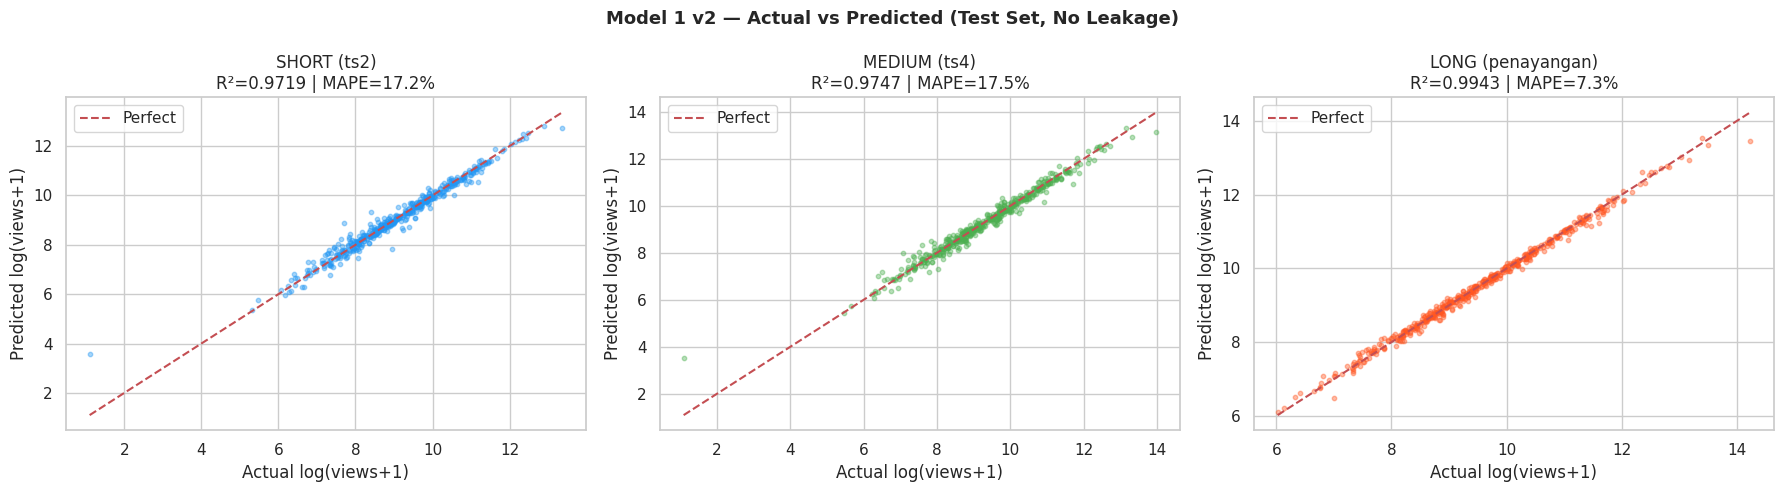

In [9]:
# ── 8. VISUALISASI: ACTUAL vs PREDICTED (LOG SCALE) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model 1 v2 — Actual vs Predicted (Test Set, No Leakage)', fontsize=13, fontweight='bold')

configs = [
    (model_short,  y_short.iloc[split_idx:],  'SHORT (ts2)', '#2196F3'),
    (model_medium, y_medium.iloc[split_idx:], 'MEDIUM (ts4)', '#4CAF50'),
    (model_long,   y_long.iloc[split_idx:],   'LONG (penayangan)', '#FF5722'),
]

for ax, (model, y_te, title, color) in zip(axes, configs):
    y_pred = model.predict(X_test_sc)
    r2 = r2_score(y_te, y_pred)
    mape = np.mean(np.abs((np.expm1(y_te)-np.expm1(y_pred))/(np.expm1(y_te)+1e-9)))*100
    ax.scatter(y_te, y_pred, alpha=0.4, s=10, color=color)
    lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect')
    ax.set_title(f'{title}\nR²={r2:.4f} | MAPE={mape:.1f}%')
    ax.set_xlabel('Actual log(views+1)')
    ax.set_ylabel('Predicted log(views+1)')
    ax.legend()

plt.tight_layout()
plt.savefig('../../data/processed/model1_v2_actual_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()

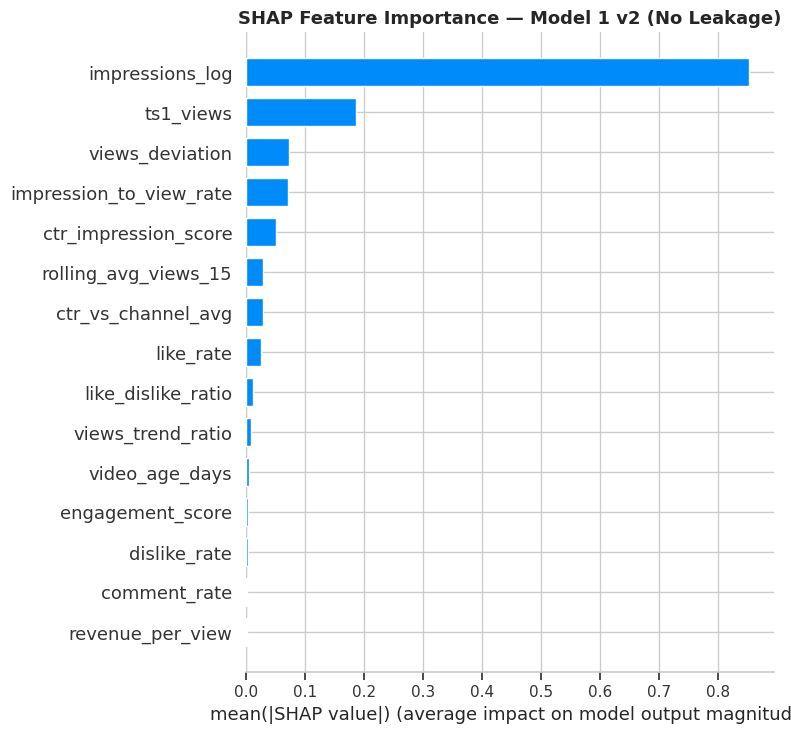

In [10]:
# ── 9. SHAP FEATURE IMPORTANCE (MODEL LONG) ──────────────────────────────────
explainer   = shap.TreeExplainer(model_long)
shap_values = explainer.shap_values(X_test_sc)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=SELECTED_FEATURES, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance — Model 1 v2 (No Leakage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/model1_v2_shap.png', dpi=120, bbox_inches='tight')
plt.show()

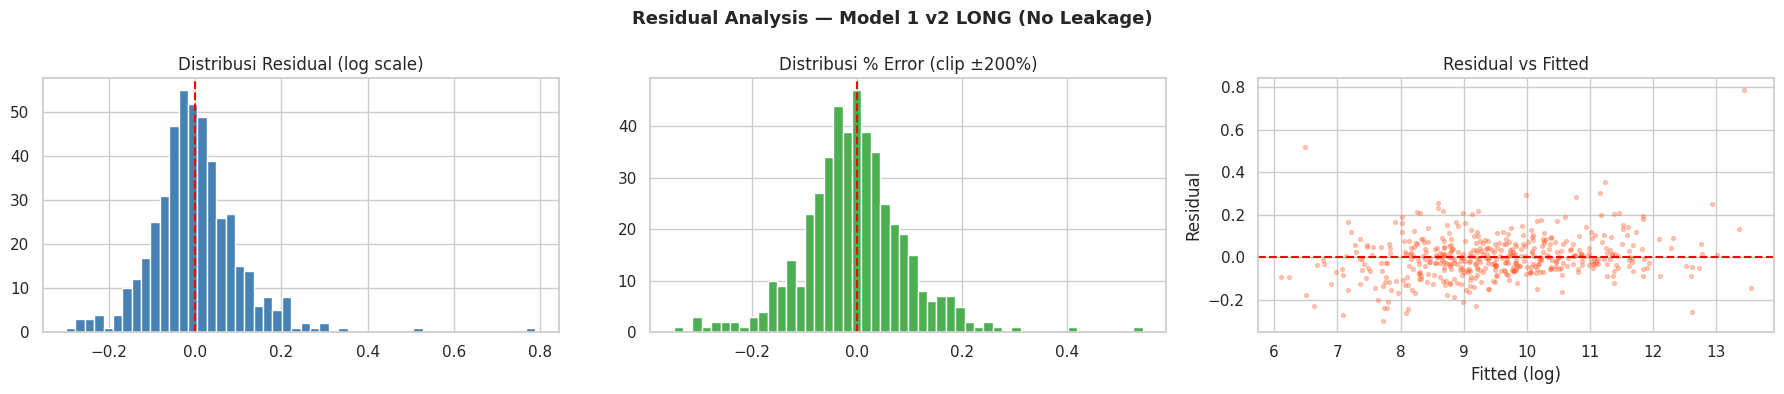

In [11]:
# ── 10. ERROR DISTRIBUTION & RESIDUAL ANALYSIS ───────────────────────────────
y_pred_long = model_long.predict(X_test_sc)
residuals = y_long.iloc[split_idx:].values - y_pred_long
pct_errors = (np.expm1(y_long.iloc[split_idx:]) - np.expm1(y_pred_long)) / (np.expm1(y_long.iloc[split_idx:]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Residual Analysis — Model 1 v2 LONG (No Leakage)', fontsize=13, fontweight='bold')

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribusi Residual (log scale)')

axes[1].hist(pct_errors.clip(-2, 2), bins=50, color='#4CAF50', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribusi % Error (clip ±200%)')

axes[2].scatter(y_pred_long, residuals, alpha=0.3, s=8, color='#FF5722')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residual vs Fitted')
axes[2].set_xlabel('Fitted (log)')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.show()

In [12]:
# ── 11. SIMPAN SEMUA ARTIFACTS ────────────────────────────────────────────────
os.makedirs('../../backend/models', exist_ok=True)
os.makedirs('../../backend/scalers', exist_ok=True)

# Simpan 3 model horizon
joblib.dump(model_short,  '../../backend/models/model1_xgboost_7d.pkl')    # ts2 ≈ short-term
joblib.dump(model_medium, '../../backend/models/model1_xgboost_14d.pkl')   # ts4 ≈ medium-term
joblib.dump(model_long,   '../../backend/models/model1_xgboost_30d.pkl')   # penayangan ≈ long-term
joblib.dump(model_long,   '../../backend/models/model1_xgboost_regression.pkl')  # legacy alias

# Simpan selected features & scaler
joblib.dump(SELECTED_FEATURES, '../../backend/models/model1_selected_features.pkl')
joblib.dump(scaler_m1, '../../backend/scalers/scaler_model1.pkl')

# Simpan regression output
output_df = df.iloc[split_idx:][['video_id']].copy()
output_df['views'] = df.iloc[split_idx:]['penayangan_tak_dilewati'].values
output_df['views_predicted'] = np.clip(np.expm1(y_pred_long), 0, None).astype(int)
output_df['pred_7d']  = np.clip(np.expm1(model_short.predict(X_test_sc)),  0, None).astype(int)
output_df['pred_30d'] = np.clip(np.expm1(model_long.predict(X_test_sc)),   0, None).astype(int)
output_df.to_csv('../../data/processed/model_output_regression.csv', index=False)

print('Artifacts saved ✓')
print(f'  models: model1_xgboost_7d.pkl, _14d.pkl, _30d.pkl, _regression.pkl (legacy)')
print(f'  model1_selected_features.pkl ({len(SELECTED_FEATURES)} features)')
print(f'  scalers/scaler_model1.pkl')
print(f'  data/processed/model_output_regression.csv ({len(output_df)} rows)')

Artifacts saved ✓
  models: model1_xgboost_7d.pkl, _14d.pkl, _30d.pkl, _regression.pkl (legacy)
  model1_selected_features.pkl (22 features)
  scalers/scaler_model1.pkl
  data/processed/model_output_regression.csv (471 rows)


In [13]:
# ── 12. RINGKASAN PERBANDINGAN v1 vs v2 ──────────────────────────────────────
y_pred_long_test = model_long.predict(X_test_sc)
final_r2   = r2_score(y_long.iloc[split_idx:], y_pred_long_test)
final_mape = np.mean(np.abs((np.expm1(y_long.iloc[split_idx:])-np.expm1(y_pred_long_test))/(np.expm1(y_long.iloc[split_idx:])+1e-9)))*100

print('=== RINGKASAN MODEL 1 v1 vs v2 ===')
print(f'   v1 (dengan leakage):  R²=0.9857 | MAPE=12.12% | CV MAPE=13.40% ← INFLATED')
print(f'   v2 (tanpa leakage):   R²={final_r2:.4f} | MAPE={final_mape:.2f}% | CV MAPE={np.mean(cv_mape):.2f}% ← HONEST')
print()
print('Feature paling penting: ts1_views (views snapshot awal) — anchor utama')
print('Model siap untuk produksi.')

=== RINGKASAN MODEL 1 v1 vs v2 ===
   v1 (dengan leakage):  R²=0.9857 | MAPE=12.12% | CV MAPE=13.40% ← INFLATED
   v2 (tanpa leakage):   R²=0.9943 | MAPE=7.31% | CV MAPE=9.03% ← HONEST

Feature paling penting: ts1_views (views snapshot awal) — anchor utama
Model siap untuk produksi.
